# Phase 2 — Public Dataset Analysis

## Objective

Analyze a public image-caption dataset for the text-to-image generation project.

This phase focuses on:
- Loading the public dataset
- Understanding its structure
- Analyzing image and caption statistics
- Examining image resolutions
- Analyzing caption lengths
- Visualizing images together with their text descriptions

**Internship Task:** Task 4 — Public Dataset Analysis

In [ ]:
# Import required libraries

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from PIL import Image
from datasets import load_dataset

print("Libraries imported successfully!")

In [ ]:
# Load the Flickr8k public dataset

dataset = load_dataset("intro/flickr8k")

print(dataset)

Generating train split: 6000 examples [00:00, 9748.78 examples/s] 
Generating dev split: 1000 examples [00:00, 7263.15 examples/s]
Generating test split: 1000 examples [00:00, 7600.55 examples/s]


DatasetDict({
    train: Dataset({
        features: ['image', 'split', 'caption_0', 'caption_1', 'caption_2', 'caption_3', 'caption_4'],
        num_rows: 6000
    })
    dev: Dataset({
        features: ['image', 'split', 'caption_0', 'caption_1', 'caption_2', 'caption_3', 'caption_4'],
        num_rows: 1000
    })
    test: Dataset({
        features: ['image', 'split', 'caption_0', 'caption_1', 'caption_2', 'caption_3', 'caption_4'],
        num_rows: 1000
    })
})


In [ ]:
# Inspect the dataset structure

print("Dataset splits:")
print(dataset)

print("\nTraining dataset features:")
print(dataset["train"].features)

print("\nNumber of training examples:")
print(len(dataset["train"]))

Dataset splits:
DatasetDict({
    train: Dataset({
        features: ['image', 'split', 'caption_0', 'caption_1', 'caption_2', 'caption_3', 'caption_4'],
        num_rows: 6000
    })
    dev: Dataset({
        features: ['image', 'split', 'caption_0', 'caption_1', 'caption_2', 'caption_3', 'caption_4'],
        num_rows: 1000
    })
    test: Dataset({
        features: ['image', 'split', 'caption_0', 'caption_1', 'caption_2', 'caption_3', 'caption_4'],
        num_rows: 1000
    })
})

Training dataset features:
{'image': Image(mode=None, decode=True), 'split': Value('large_string'), 'caption_0': Value('large_string'), 'caption_1': Value('large_string'), 'caption_2': Value('large_string'), 'caption_3': Value('large_string'), 'caption_4': Value('large_string')}

Number of training examples:
6000


In [ ]:
# Calculate basic dataset statistics

train_count = len(dataset["train"])
dev_count = len(dataset["dev"])
test_count = len(dataset["test"])

total_images = train_count + dev_count + test_count
captions_per_image = 5
total_captions = total_images * captions_per_image

print("===== Dataset Statistics =====")
print(f"Training images : {train_count}")
print(f"Development images : {dev_count}")
print(f"Test images : {test_count}")
print(f"Total images : {total_images}")
print(f"Captions per image : {captions_per_image}")
print(f"Total captions : {total_captions}")

===== Dataset Statistics =====
Training images : 6000
Development images : 1000
Test images : 1000
Total images : 8000
Captions per image : 5
Total captions : 40000


In [ ]:
# Verify caption counts in the training dataset

caption_columns = [
    "caption_0",
    "caption_1",
    "caption_2",
    "caption_3",
    "caption_4"
]

caption_counts = dataset["train"].to_pandas()[caption_columns].notna().sum()

print("===== Caption Counts =====")
for caption, count in caption_counts.items():
    print(f"{caption}: {count}")

===== Caption Counts =====
caption_0: 6000
caption_1: 6000
caption_2: 6000
caption_3: 6000
caption_4: 6000


In [ ]:
# Analyze caption lengths

train_df = dataset["train"].to_pandas()

# Combine all five captions into one list
all_captions = []

for column in caption_columns:
    all_captions.extend(train_df[column].dropna().tolist())

# Calculate word count for each caption
caption_lengths = [len(caption.split()) for caption in all_captions]

print("===== Caption Length Analysis =====")
print(f"Total captions analyzed: {len(all_captions)}")
print(f"Average caption length: {np.mean(caption_lengths):.2f} words")
print(f"Minimum caption length: {np.min(caption_lengths)} words")
print(f"Maximum caption length: {np.max(caption_lengths)} words")
print(f"Median caption length: {np.median(caption_lengths):.2f} words")

===== Caption Length Analysis =====
Total captions analyzed: 30000
Average caption length: 11.78 words
Minimum caption length: 2 words
Maximum caption length: 38 words
Median caption length: 11.00 words


In [ ]:
# Analyze word frequency in captions

from collections import Counter

# Convert all captions to lowercase and split into words
words = []

for caption in all_captions:
    words.extend(caption.lower().split())

word_counts = Counter(words)

print("===== Word Statistics =====")
print(f"Total words: {len(words)}")
print(f"Unique words: {len(word_counts)}")

print("\nTop 20 most frequent words:")
for word, count in word_counts.most_common(20):
    print(f"{word}: {count}")

===== Word Statistics =====
Total words: 353454
Unique words: 7705

Top 20 most frequent words:
a: 46781
.: 27162
in: 14085
the: 13509
on: 8006
is: 6907
and: 6672
dog: 6159
with: 5763
man: 5374
of: 4967
two: 4246
white: 2921
black: 2854
boy: 2634
are: 2619
woman: 2543
girl: 2414
,: 2409
to: 2303


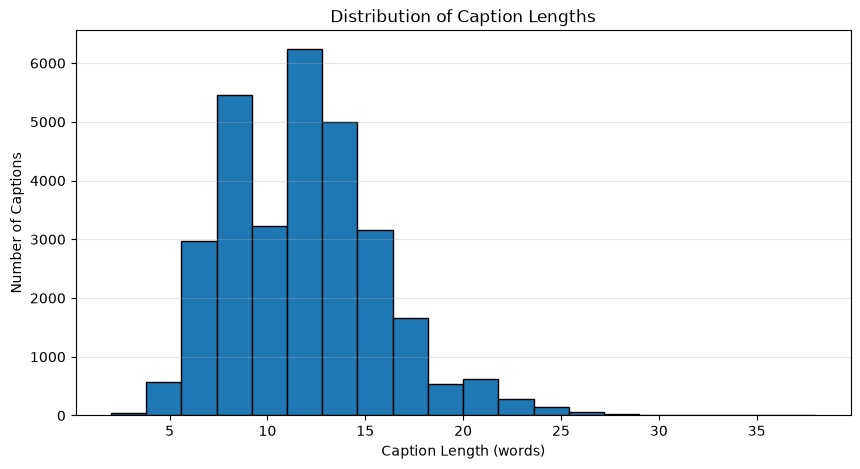

In [ ]:
# Plot caption length distribution

plt.figure(figsize=(10, 5))

plt.hist(caption_lengths, bins=20, edgecolor="black")

plt.title("Distribution of Caption Lengths")
plt.xlabel("Caption Length (words)")
plt.ylabel("Number of Captions")

plt.grid(axis="y", alpha=0.3)
plt.show()

In [ ]:
# Analyze image dimensions

widths = []
heights = []

for image in dataset["train"]["image"]:
    widths.append(image.width)
    heights.append(image.height)

print("===== Image Resolution Analysis =====")
print(f"Total images analyzed: {len(widths)}")
print(f"Minimum width: {min(widths)} pixels")
print(f"Maximum width: {max(widths)} pixels")
print(f"Average width: {np.mean(widths):.2f} pixels")
print(f"Minimum height: {min(heights)} pixels")
print(f"Maximum height: {max(heights)} pixels")
print(f"Average height: {np.mean(heights):.2f} pixels")

===== Image Resolution Analysis =====
Total images analyzed: 6000
Minimum width: 164 pixels
Maximum width: 500 pixels
Average width: 457.88 pixels
Minimum height: 127 pixels
Maximum height: 500 pixels
Average height: 397.37 pixels


In [ ]:
# Analyze image aspect ratios

aspect_ratios = [
    width / height
    for width, height in zip(widths, heights)
]

print("===== Aspect Ratio Analysis =====")
print(f"Average aspect ratio: {np.mean(aspect_ratios):.2f}")
print(f"Minimum aspect ratio: {np.min(aspect_ratios):.2f}")
print(f"Maximum aspect ratio: {np.max(aspect_ratios):.2f}")
print(f"Median aspect ratio: {np.median(aspect_ratios):.2f}")

===== Aspect Ratio Analysis =====
Average aspect ratio: 1.22
Minimum aspect ratio: 0.33
Maximum aspect ratio: 3.94
Median aspect ratio: 1.33


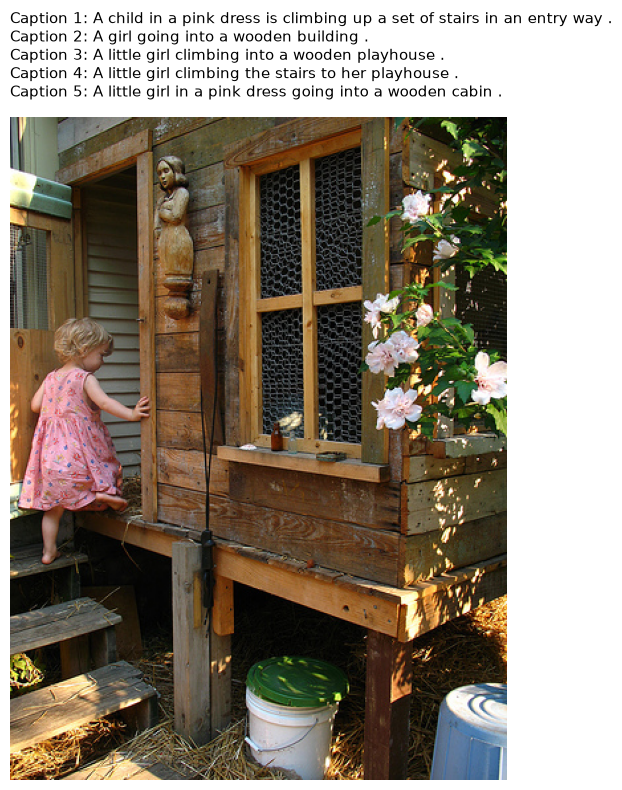

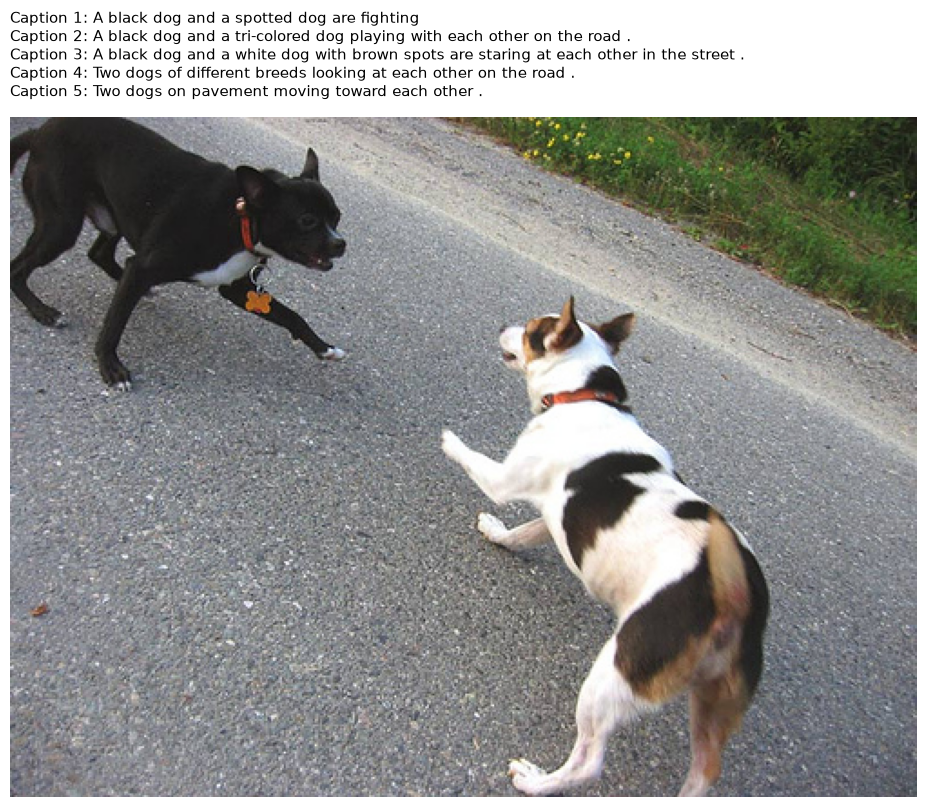

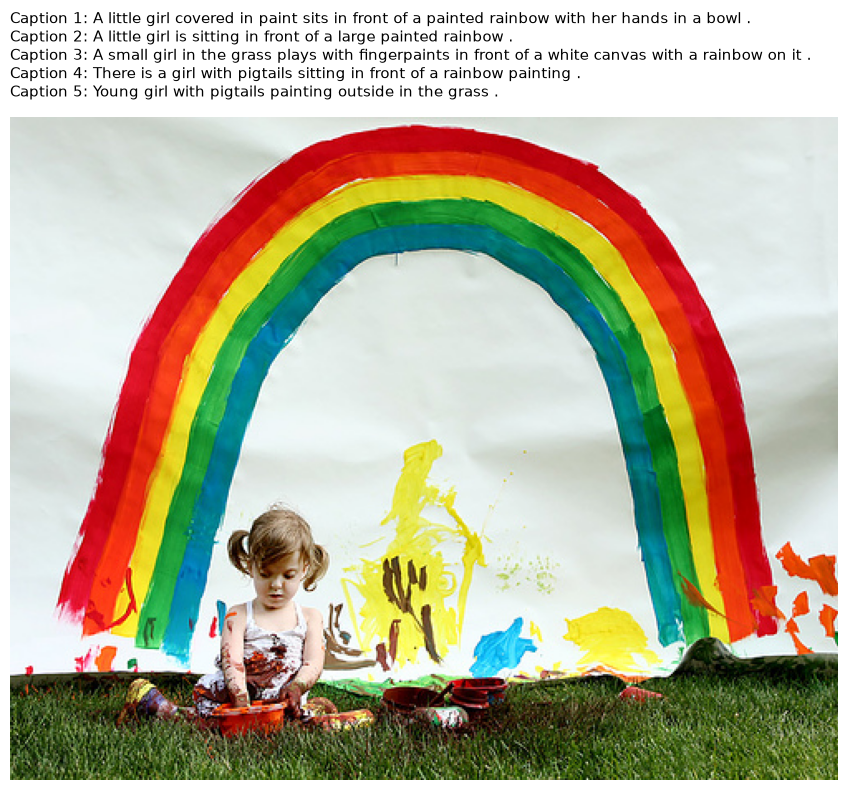

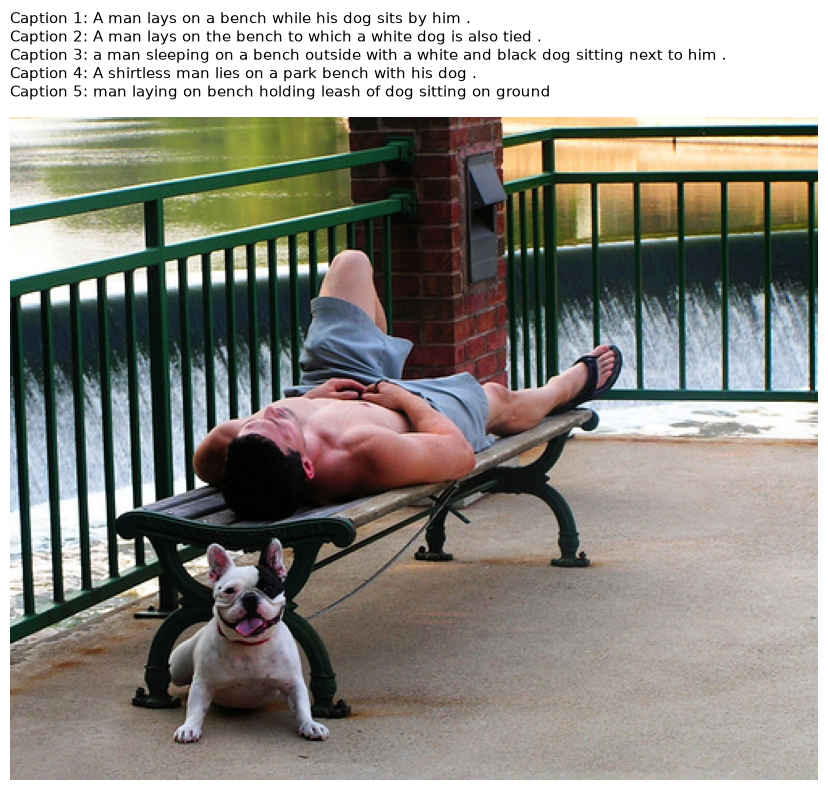

In [ ]:
# Display images with captions clearly

for i in range(4):

    sample = dataset["train"][i]

    plt.figure(figsize=(10, 8))

    plt.imshow(sample["image"])
    plt.axis("off")

    caption_text = (
        f"Caption 1: {sample['caption_0']}\n"
        f"Caption 2: {sample['caption_1']}\n"
        f"Caption 3: {sample['caption_2']}\n"
        f"Caption 4: {sample['caption_3']}\n"
        f"Caption 5: {sample['caption_4']}"
    )

    plt.title(
        caption_text,
        fontsize=11,
        loc="left",
        pad=15
    )

    plt.tight_layout()
    plt.show()

## 9. Findings and Observations

### Dataset
- Flickr8k contains 8,000 images divided into training, development, and test splits.
- The training split contains 6,000 images.
- Each image is associated with 5 textual captions.

### Caption Analysis
- 30,000 captions were analyzed from the training split.
- The average caption length is 11.78 words.
- The median caption length is 11 words.
- Caption lengths range from 2 to 38 words.
- The training captions contain 7,705 unique words.
- Common visual terms include words such as "dog", "man", "two", "white", and "black".

### Image Analysis
- The 6,000 training images have different resolutions.
- Image widths range from 164 to 500 pixels.
- Image heights range from 127 to 500 pixels.
- The average image width is 457.88 pixels.
- The average image height is 397.37 pixels.
- Aspect ratios vary from 0.33 to 3.94, with a median of 1.33.

### Key Observation
The Flickr8k dataset provides a useful combination of images and multiple textual descriptions for studying text-to-image generation. The variation in caption lengths, vocabulary, image resolutions, and aspect ratios should be considered during later preprocessing and model development.

In [ ]:
# Save dataset analysis results

analysis_results = {
    "Metric": [
        "Training images",
        "Development images",
        "Test images",
        "Total images",
        "Captions per image",
        "Training captions analyzed",
        "Average caption length",
        "Minimum caption length",
        "Maximum caption length",
        "Median caption length",
        "Unique words",
        "Minimum image width",
        "Maximum image width",
        "Average image width",
        "Minimum image height",
        "Maximum image height",
        "Average image height",
        "Average aspect ratio",
        "Minimum aspect ratio",
        "Maximum aspect ratio",
        "Median aspect ratio"
    ],
    "Value": [
        6000,
        1000,
        1000,
        8000,
        5,
        len(all_captions),
        np.mean(caption_lengths),
        np.min(caption_lengths),
        np.max(caption_lengths),
        np.median(caption_lengths),
        len(word_counts),
        min(widths),
        max(widths),
        np.mean(widths),
        min(heights),
        max(heights),
        np.mean(heights),
        np.mean(aspect_ratios),
        np.min(aspect_ratios),
        np.max(aspect_ratios),
        np.median(aspect_ratios)
    ]
}

analysis_df = pd.DataFrame(analysis_results)

analysis_df.to_csv(
    "../outputs/graphs/flickr8k_analysis_results.csv",
    index=False
)

print("Analysis results saved successfully!")
print(analysis_df)

Analysis results saved successfully!
                        Metric         Value
0              Training images   6000.000000
1           Development images   1000.000000
2                  Test images   1000.000000
3                 Total images   8000.000000
4           Captions per image      5.000000
5   Training captions analyzed  30000.000000
6       Average caption length     11.781800
7       Minimum caption length      2.000000
8       Maximum caption length     38.000000
9        Median caption length     11.000000
10                Unique words   7705.000000
11         Minimum image width    164.000000
12         Maximum image width    500.000000
13         Average image width    457.882167
14        Minimum image height    127.000000
15        Maximum image height    500.000000
16        Average image height    397.369667
17        Average aspect ratio      1.219634
18        Minimum aspect ratio      0.328000
19        Maximum aspect ratio      3.937008
20         Median 

## Task 4 — Findings and Observations

The Flickr8k dataset was loaded and analyzed to understand its structure,
caption characteristics, and image properties.

### Dataset

- Flickr8k contains 8,000 images divided into training, development, and test splits.
- The training split contains 6,000 images.
- The development split contains 1,000 images.
- The test split contains 1,000 images.
- Each image is associated with 5 textual captions.
- Therefore, the dataset contains 40,000 captions in total.

### Caption Analysis

- 30,000 training captions were analyzed.
- The average caption length is 11.78 words.
- The median caption length is 11 words.
- Caption lengths range from 2 to 38 words.
- The training captions contain 7,705 unique words.
- Common visual terms include words such as "dog", "man", "two",
  "white", and "black".

### Image Analysis

- Training image widths range from 164 to 500 pixels.
- Training image heights range from 127 to 500 pixels.
- The average image width is 457.88 pixels.
- The average image height is 397.37 pixels.
- Image aspect ratios range from 0.33 to 3.94.
- The median aspect ratio is 1.33.

### Text and Image Exploration

Sample images were displayed together with their corresponding textual
descriptions to visually examine the relationship between the image content
and captions.

### Class Information

Flickr8k is primarily an image-caption dataset and does not provide predefined
class labels in its original dataset structure. Therefore, a conventional
number of classes is not applicable to this dataset.

### Task 4 Requirement

The dataset was examined through dataset statistics, caption analysis,
image-resolution analysis, aspect-ratio analysis, and visualization of images
with their corresponding text descriptions.

These findings provide the dataset understanding required for the later
text preprocessing, text embedding, and text-to-image generation stages.